In [1]:
# Arpit Huss (E23CSEU0554)

!pip install -q wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wfdb
import re

from collections import Counter
from PIL import Image, ImageDraw

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

column_names = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

df = pd.read_csv(
    url,
    names=column_names,
    na_values="?"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape: (303, 14)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [6]:
print("Missing Values in Each Column:")

print(df.isnull().sum())

Missing Values in Each Column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [7]:
imputer = SimpleImputer(strategy="median")

df[df.columns] = imputer.fit_transform(df)

print("Missing values handled successfully!")

print("\nMissing Values After Processing:")
print(df.isnull().sum())

Missing values handled successfully!

Missing Values After Processing:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [8]:
df["target"] = (df["target"] > 0).astype(int)

print(df["target"].value_counts())

target
0    164
1    139
Name: count, dtype: int64


In [9]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


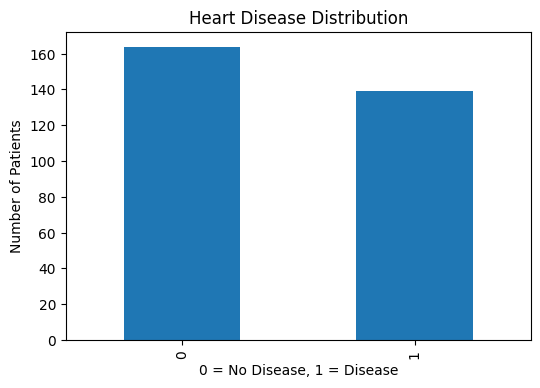

In [10]:
plt.figure(figsize=(6, 4))

df["target"].value_counts().sort_index().plot(kind="bar")

plt.title("Heart Disease Distribution")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Number of Patients")

plt.show()

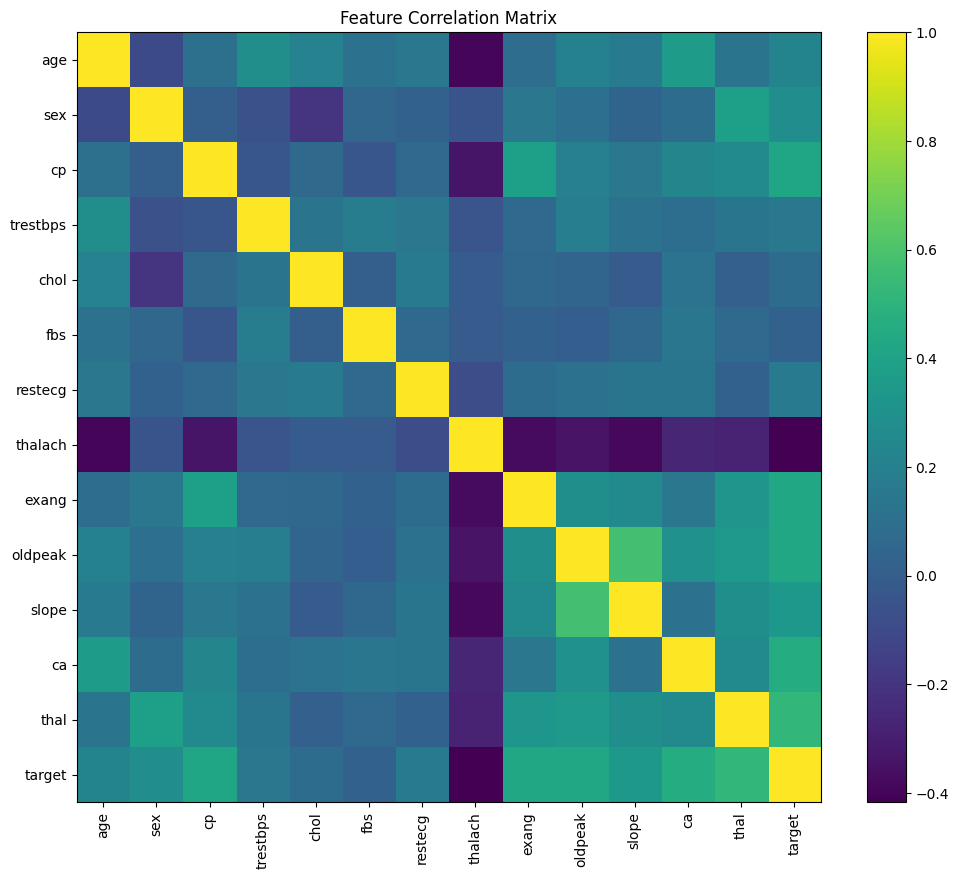

In [11]:
plt.figure(figsize=(12, 10))

plt.imshow(df.corr(), aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(df.columns)),
    df.columns,
    rotation=90
)

plt.yticks(
    range(len(df.columns)),
    df.columns
)

plt.title("Feature Correlation Matrix")

plt.show()

In [12]:
X = df.drop("target", axis=1)

y = df["target"]

print("Feature Shape:", X.shape)

print("Target Shape:", y.shape)

Feature Shape: (303, 13)
Target Shape: (303,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)

print("Testing Data:", X_test.shape)

Training Data: (242, 13)
Testing Data: (61, 13)


In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Data standardized successfully!")

Data standardized successfully!


In [15]:
model = LogisticRegression(max_iter=2000)

model.fit(
    X_train_scaled,
    y_train
)

print("Model trained successfully!")

Model trained successfully!


In [16]:
y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Predictions completed!")

Predictions completed!


In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 86.89 %


In [18]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(roc_auc, 3))

ROC-AUC Score: 0.951


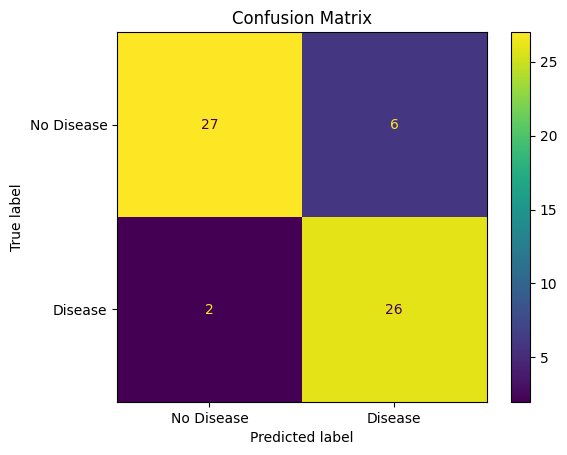

In [19]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

In [20]:
record = wfdb.rdrecord(
    "100",
    pn_dir="mitdb"
)

annotation = wfdb.rdann(
    "100",
    "atr",
    pn_dir="mitdb"
)

print("ECG Record Loaded Successfully!")

ECG Record Loaded Successfully!


In [21]:
print("Signal Shape:", record.p_signal.shape)

print("Sampling Frequency:", record.fs)

print("Signal Names:", record.sig_name)

print("Number of Annotations:", len(annotation.sample))

Signal Shape: (650000, 2)
Sampling Frequency: 360
Signal Names: ['MLII', 'V5']
Number of Annotations: 2274


In [22]:
signal = record.p_signal[:, 0]

print("Total ECG Samples:", len(signal))

Total ECG Samples: 650000


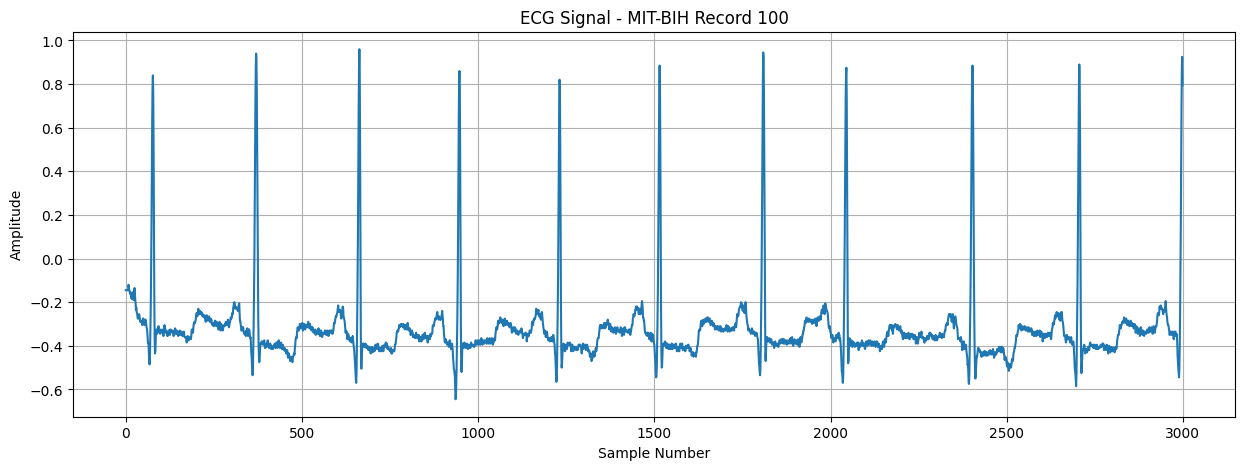

In [23]:
samples_to_plot = 3000

plt.figure(figsize=(15, 5))

plt.plot(signal[:samples_to_plot])

plt.title("ECG Signal - MIT-BIH Record 100")

plt.xlabel("Sample Number")

plt.ylabel("Amplitude")

plt.grid()

plt.show()

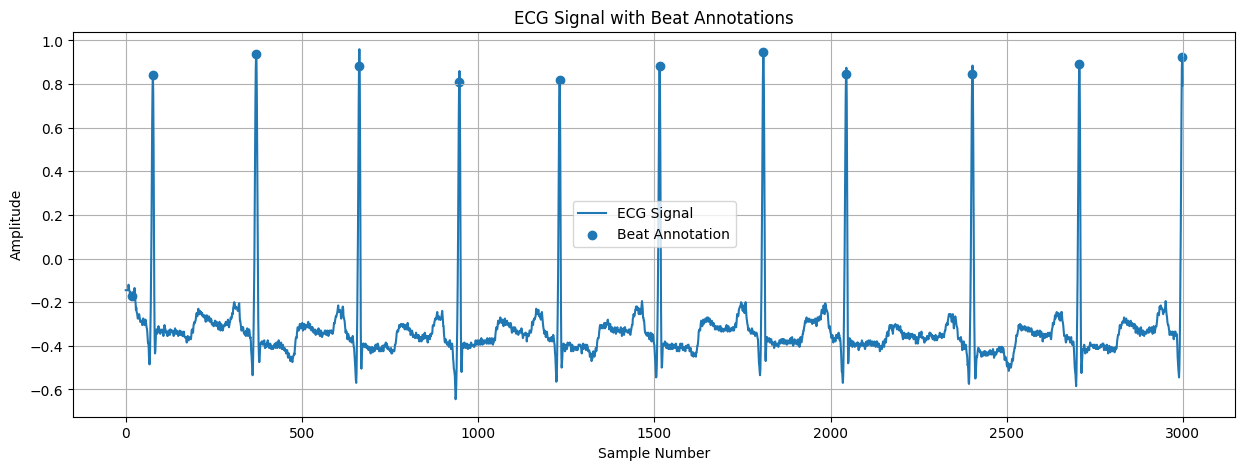

In [24]:
beat_samples = annotation.sample

valid_beats = beat_samples[
    beat_samples < samples_to_plot
]

plt.figure(figsize=(15, 5))

plt.plot(
    signal[:samples_to_plot],
    label="ECG Signal"
)

plt.scatter(
    valid_beats,
    signal[valid_beats],
    label="Beat Annotation"
)

plt.title("ECG Signal with Beat Annotations")

plt.xlabel("Sample Number")

plt.ylabel("Amplitude")

plt.legend()

plt.grid()

plt.show()

In [25]:
rr_intervals = np.diff(annotation.sample) / record.fs

print("First 10 RR Intervals:")
print(np.round(rr_intervals[:10], 3))

print("\nMean RR Interval:")
print(round(np.mean(rr_intervals), 3), "seconds")

print("\nStandard Deviation:")
print(round(np.std(rr_intervals), 3), "seconds")

First 10 RR Intervals:
[0.164 0.814 0.811 0.789 0.792 0.789 0.817 0.653 0.994 0.844]

Mean RR Interval:
0.794 seconds

Standard Deviation:
0.051 seconds


In [26]:
mean_rr = np.mean(rr_intervals)

heart_rate = 60 / mean_rr

print("Estimated Average Heart Rate:")
print(round(heart_rate, 2), "BPM")

Estimated Average Heart Rate:
75.54 BPM


In [27]:
clinical_note = """
The patient is a 55 year old male presenting with chest pain,
shortness of breath, fatigue and mild dizziness.

The patient has a history of high blood pressure and high cholesterol.
An ECG examination is recommended for further cardiac evaluation.
"""

print(clinical_note)


The patient is a 55 year old male presenting with chest pain,
shortness of breath, fatigue and mild dizziness.

The patient has a history of high blood pressure and high cholesterol.
An ECG examination is recommended for further cardiac evaluation.



In [28]:
tokens = re.findall(
    r'\b[a-zA-Z]+\b',
    clinical_note.lower()
)

print(tokens)

['the', 'patient', 'is', 'a', 'year', 'old', 'male', 'presenting', 'with', 'chest', 'pain', 'shortness', 'of', 'breath', 'fatigue', 'and', 'mild', 'dizziness', 'the', 'patient', 'has', 'a', 'history', 'of', 'high', 'blood', 'pressure', 'and', 'high', 'cholesterol', 'an', 'ecg', 'examination', 'is', 'recommended', 'for', 'further', 'cardiac', 'evaluation']


In [29]:
word_frequency = Counter(tokens)

print("Word Frequency:\n")

for word, count in word_frequency.most_common():
    print(word, ":", count)

Word Frequency:

the : 2
patient : 2
is : 2
a : 2
of : 2
and : 2
high : 2
year : 1
old : 1
male : 1
presenting : 1
with : 1
chest : 1
pain : 1
shortness : 1
breath : 1
fatigue : 1
mild : 1
dizziness : 1
has : 1
history : 1
blood : 1
pressure : 1
cholesterol : 1
an : 1
ecg : 1
examination : 1
recommended : 1
for : 1
further : 1
cardiac : 1
evaluation : 1


In [30]:
medical_terms = [
    "chest",
    "pain",
    "breath",
    "fatigue",
    "dizziness",
    "blood",
    "pressure",
    "cholesterol",
    "ecg",
    "cardiac"
]

found_terms = [
    term
    for term in medical_terms
    if term in tokens
]

print("Medical Terms Found:")

print(found_terms)

Medical Terms Found:
['chest', 'pain', 'breath', 'fatigue', 'dizziness', 'blood', 'pressure', 'cholesterol', 'ecg', 'cardiac']


In [31]:
from PIL import Image, ImageDraw

sample_image = Image.new(
    "RGB",
    (512, 512),
    "black"
)

draw = ImageDraw.Draw(sample_image)

# Outer scan area
draw.ellipse(
    (80, 80, 432, 432),
    outline="white",
    width=5
)

# Left structure
draw.ellipse(
    (150, 130, 245, 350),
    outline="gray",
    width=8
)

# Right structure
draw.ellipse(
    (267, 130, 362, 350),
    outline="gray",
    width=8
)

# Center line
draw.line(
    (256, 100, 256, 410),
    fill="white",
    width=3
)

sample_image.save("sample_medical_image.png")

print("Sample image created and saved successfully!")

Sample image created and saved successfully!


In [32]:
image = Image.open("sample_medical_image.png")

print("Image Format:", image.format)

print("Image Size:", image.size)

print("Image Mode:", image.mode)

Image Format: PNG
Image Size: (512, 512)
Image Mode: RGB


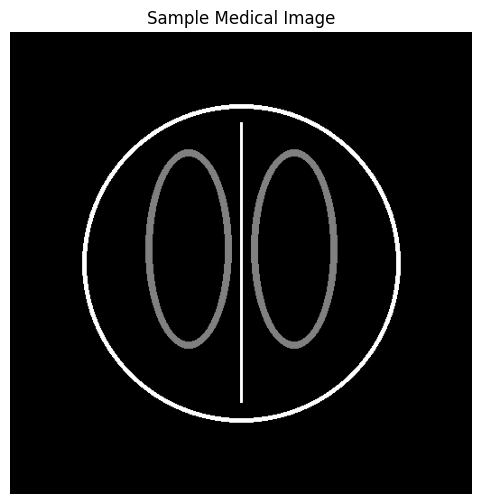

In [33]:
plt.figure(figsize=(6, 6))

plt.imshow(image)

plt.title("Sample Medical Image")

plt.axis("off")

plt.show()

In [34]:
resized_image = image.resize((256, 256))

print("Resized Image Size:", resized_image.size)

Resized Image Size: (256, 256)


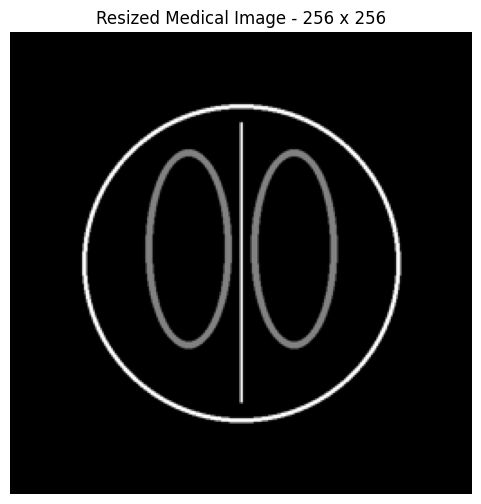

In [35]:
plt.figure(figsize=(6, 6))

plt.imshow(resized_image)

plt.title("Resized Medical Image - 256 x 256")

plt.axis("off")

plt.show()

In [36]:
print("""
MULTIMODAL HEALTHCARE DATA INTEGRATION

In this experiment, different types of healthcare data were processed:

1. Tabular and Medical Data:
   Patient information such as age, cholesterol, blood pressure
   and other clinical features was used for heart disease prediction.

2. Signal Data:
   ECG signals were loaded from the MIT-BIH Arrhythmia Database.
   RR intervals and estimated heart rate were calculated.

3. Textual Data:
   A clinical note was tokenized, word frequencies were calculated,
   and important medical terms were extracted.

4. Image Data:
   An image was created, loaded, displayed, inspected and resized.

In a future multimodal AI healthcare system, these different data
sources can be combined. Tabular data can provide patient information,
ECG signals can provide cardiac features, clinical notes can provide
symptom information, and medical images can provide visual information.

Combining multiple healthcare data modalities can provide a more
comprehensive input for future AI-based disease prediction and
clinical decision support systems.
""")


MULTIMODAL HEALTHCARE DATA INTEGRATION

In this experiment, different types of healthcare data were processed:

1. Tabular and Medical Data:
   Patient information such as age, cholesterol, blood pressure
   and other clinical features was used for heart disease prediction.

2. Signal Data:
   ECG signals were loaded from the MIT-BIH Arrhythmia Database.
   RR intervals and estimated heart rate were calculated.

3. Textual Data:
   A clinical note was tokenized, word frequencies were calculated,
   and important medical terms were extracted.

4. Image Data:
   An image was created, loaded, displayed, inspected and resized.

In a future multimodal AI healthcare system, these different data
sources can be combined. Tabular data can provide patient information,
ECG signals can provide cardiac features, clinical notes can provide
symptom information, and medical images can provide visual information.

Combining multiple healthcare data modalities can provide a more
comprehensive input for